# AMM Simulator — Linear-Impact AMM

This notebook runs the Linear-Impact AMM simulation:

1. Imports & JAX verification
2. Single episode rollout
3. Batch rollout
4. Compare two pools with different spreads

## 1. Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import importlib

import amm_sim.scoring
import amm_sim.spec
import amm_sim.types
import amm_sim.arb
import amm_sim.engine
import amm_sim.env
import amm_sim.amms.constant_product
import amm_sim.amms.linear

importlib.reload(amm_sim.scoring)
importlib.reload(amm_sim.spec)
importlib.reload(amm_sim.types)
importlib.reload(amm_sim.arb)
importlib.reload(amm_sim.amms.constant_product)
importlib.reload(amm_sim.amms.linear)
importlib.reload(amm_sim.engine)
importlib.reload(amm_sim.env)

from amm_sim.types import SimParams
from amm_sim.env import make_env
from amm_sim.spec import marginal_ask, marginal_bid
from amm_sim.amms.constant_product import CONSTANT_PRODUCT_AMM, CPParams
from amm_sim.amms.linear import (
    LINEAR_AMM, LinearParams,
    verify_jax_compatibility,
)

print("JAX version :", jax.__version__)
print("JAX devices :", jax.devices())

JAX version : 0.7.1
JAX devices : [CpuDevice(id=0)]


## 2. JAX Verification

In [2]:
verify_jax_compatibility()

Linear AMM — all JAX compatibility checks passed.


## 3. Simulation Parameters

In [3]:
# Pool 0 (agent):     Linear AMM with spread 0.2
# Pool 1 (benchmark): default CP AMM with 30 bps fee, init_x=100, init_y=10000
params_agent = LinearParams(
    lam_pp=1, lam_mm=1,
    lam_pm=1.01, lam_mp=1.01,
    init_p_ask=100.3,   # fair price (100) + spread (0.1)
    init_p_bid=99.7,    # fair price (100) - spread (0.1)
    init_x=100.0,
    init_y=10_000.0,
)
cp_params = CPParams()  # defaults: fee_plus=0.003, fee_minus=0.003, init_x=100, init_y=10000

sim_params = SimParams(
    sigma=0.001,       # GBM volatility per step — larger = more arbitrage opportunities
    num_steps=1_000,   # steps per episode
    max_orders=16,     # max retail orders per step (Poisson arrivals clipped to this)
    lam=1,           # Poisson arrival rate — average orders per step
    mu=-0.5,            # LogNormal mean for order size — larger = bigger retail orders
    sigma_ln=0.1,      # LogNormal std for order size — controls size dispersion
    phi=0.0,           # inventory penalty — 0 = maximise edge only, >0 = penalise inventory imbalance
)

env = make_env(
    amm_specs  = [LINEAR_AMM, CONSTANT_PRODUCT_AMM],
    amm_params = [params_agent, cp_params],
)

print("Environment ready.")

Environment ready.


## 4. Single Episode Rollout

In [4]:
key = jax.random.PRNGKey(0)
_, init_state = env.reset(key, sim_params)

# Custom scan: read p_ask/p_bid directly from LinearState (stored, not via jax.grad).
# For CP, record ask and bid marginals (which the arb solver tracks) rather than mid-price
# (reserve_y/reserve_x), because the mid bounces ±fee at every arb step — visually noisy.
def scan_step(state, _):
    new_state, record = env.block_step(state, sim_params)
    lin_st = new_state.amm_states[0]
    ma0    = lin_st.p_ask                                    # stored ask price
    mb0    = lin_st.p_bid                                    # stored bid price
    cp_st  = new_state.amm_states[1]
    ma1    = marginal_ask(CONSTANT_PRODUCT_AMM, cp_st)       # CP marginal ask (arb target)
    mb1    = marginal_bid(CONSTANT_PRODUCT_AMM, cp_st)       # CP marginal bid (arb target)
    return new_state, (record, ma0, mb0, ma1, mb1)

final_state, (traj, ma0, mb0, ma1, mb1) = jax.lax.scan(
    scan_step, init_state, None, length=sim_params.num_steps
)

arb_edge    = np.array(traj.arb_edge)
retail_edge = np.array(traj.retail_edge)
total_edge  = np.array(traj.total_edge)
fair_price  = np.array(traj.fair_price)
ma0 = np.array(ma0);  mb0 = np.array(mb0)
ma1 = np.array(ma1);  mb1 = np.array(mb1)

print(f"Episode summary:")
print(f"  Total edge  : {total_edge.sum():.4f}")
print(f"  Arb edge    : {arb_edge.sum():.4f}  (should be < 0)")
print(f"  Retail edge : {retail_edge.sum():.4f}  (should be > 0)")
print(f"  Arb always <= 0: {bool((arb_edge <= 1e-6).all())}")

pool0 = final_state.amm_states[0]
print(f"\nFinal pool 0 state (should match last points on figure):")
print(f"  p_ask     = {float(pool0.p_ask):.4f}  ma0[-1] = {ma0[-1]:.4f}")
print(f"  p_bid     = {float(pool0.p_bid):.4f}  mb0[-1] = {mb0[-1]:.4f}")

Episode summary:
  Total edge  : 343.7654
  Arb edge    : -92.9334  (should be < 0)
  Retail edge : 436.6988  (should be > 0)
  Arb always <= 0: True

Final pool 0 state (should match last points on figure):
  p_ask     = 96.8809  ma0[-1] = 96.8809
  p_bid     = 94.1778  mb0[-1] = 94.1778


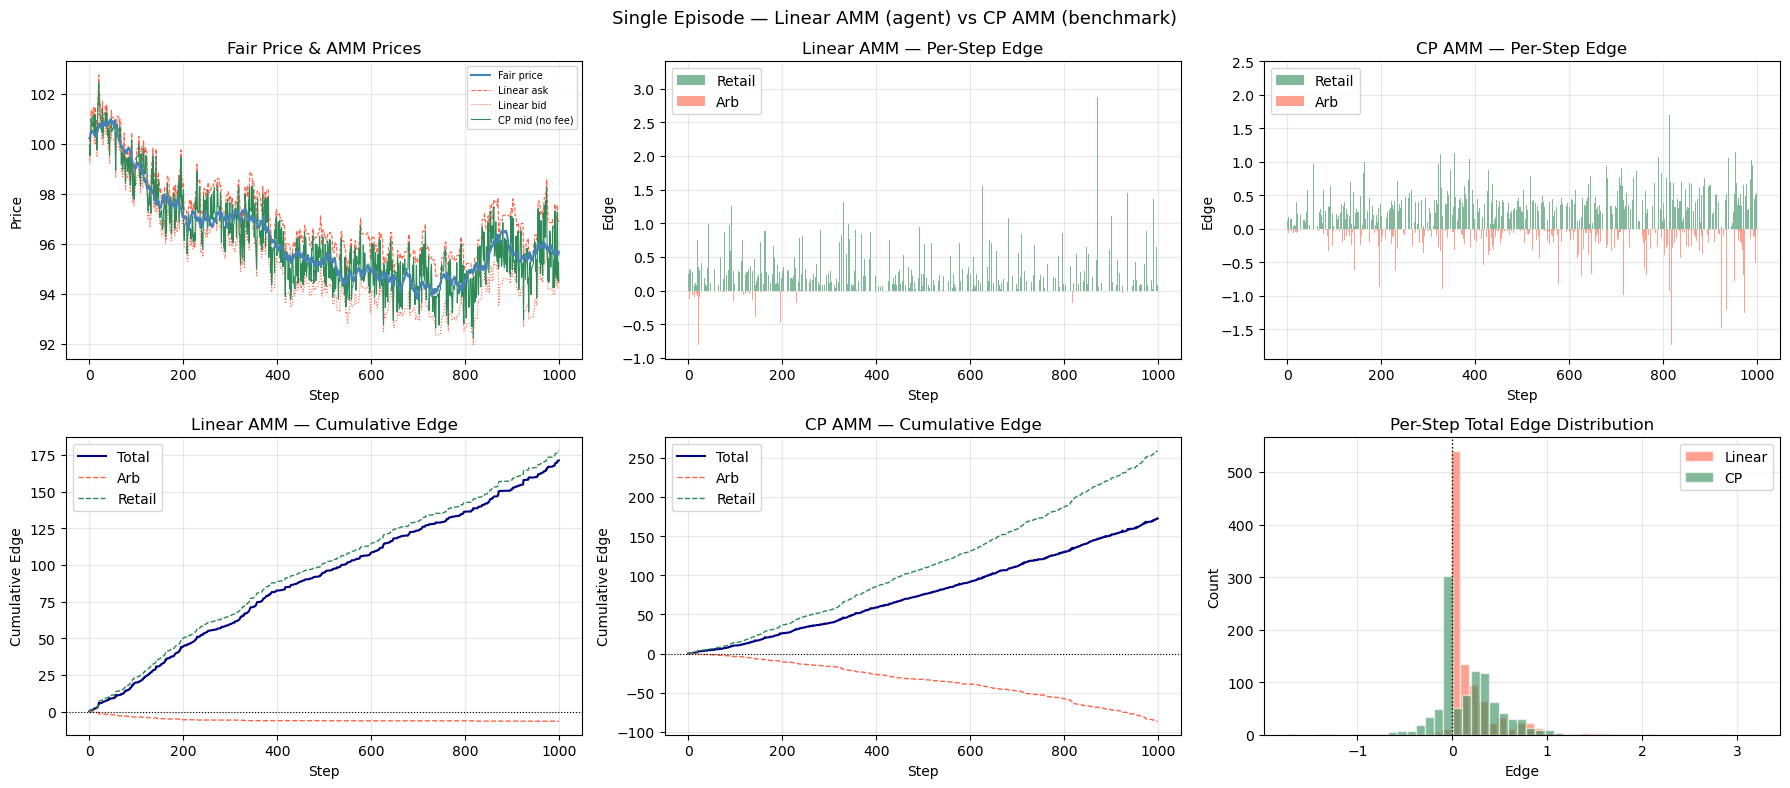

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle("Single Episode — Linear AMM (agent) vs CP AMM (benchmark)", fontsize=13)

steps = np.arange(len(fair_price))

# CP no-fee mid: sqrt(ask * bid) = reserve_y/reserve_x  (exact for symmetric fees)
cp_mid = np.sqrt(ma1 * mb1)

# Per-pool edges from CycleRecord  (num_steps, num_pools)
arb_edge_lin    = np.array(traj.arb_edges_per_pool[:,    0])
arb_edge_cp     = np.array(traj.arb_edges_per_pool[:,    1])
retail_edge_lin = np.array(traj.retail_edges_per_pool[:, 0])
retail_edge_cp  = np.array(traj.retail_edges_per_pool[:, 1])

# ── Fair price + Linear ask/bid + CP mid ───────────────────────
ax = axes[0, 0]
ax.plot(steps, fair_price, color="steelblue", lw=1.5, label="Fair price", zorder=3)
ax.plot(steps, ma0,    color="tomato",   lw=0.8, linestyle="--", label="Linear ask")
ax.plot(steps, mb0,    color="tomato",   lw=0.8, linestyle=":",  label="Linear bid")
ax.plot(steps, cp_mid, color="seagreen", lw=0.8, linestyle="-",  label="CP mid (no fee)")
ax.set_title("Fair Price & AMM Prices")
ax.set_xlabel("Step"); ax.set_ylabel("Price")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# ── Linear AMM — per-step edge ─────────────────────────────────
ax = axes[0, 1]
ax.bar(steps, retail_edge_lin, color="seagreen", alpha=0.6, label="Retail", width=1)
ax.bar(steps, arb_edge_lin,    color="tomato",   alpha=0.6, label="Arb",    width=1)
ax.set_title("Linear AMM — Per-Step Edge")
ax.set_xlabel("Step"); ax.set_ylabel("Edge")
ax.legend(); ax.grid(True, alpha=0.3)

# ── CP AMM — per-step edge ─────────────────────────────────────
ax = axes[0, 2]
ax.bar(steps, retail_edge_cp, color="seagreen", alpha=0.6, label="Retail", width=1)
ax.bar(steps, arb_edge_cp,    color="tomato",   alpha=0.6, label="Arb",    width=1)
ax.set_title("CP AMM — Per-Step Edge")
ax.set_xlabel("Step"); ax.set_ylabel("Edge")
ax.legend(); ax.grid(True, alpha=0.3)

# ── Linear AMM — cumulative edge ──────────────────────────────
ax = axes[1, 0]
total_lin = arb_edge_lin + retail_edge_lin
ax.plot(steps, np.cumsum(total_lin),       color="navy",     lw=1.5, label="Total")
ax.plot(steps, np.cumsum(arb_edge_lin),    color="tomato",   lw=1,   linestyle="--", label="Arb")
ax.plot(steps, np.cumsum(retail_edge_lin), color="seagreen", lw=1,   linestyle="--", label="Retail")
ax.axhline(0, color="black", lw=0.8, linestyle=":")
ax.set_title("Linear AMM — Cumulative Edge")
ax.set_xlabel("Step"); ax.set_ylabel("Cumulative Edge")
ax.legend(); ax.grid(True, alpha=0.3)

# ── CP AMM — cumulative edge ───────────────────────────────────
ax = axes[1, 1]
total_cp = arb_edge_cp + retail_edge_cp
ax.plot(steps, np.cumsum(total_cp),       color="navy",     lw=1.5, label="Total")
ax.plot(steps, np.cumsum(arb_edge_cp),    color="tomato",   lw=1,   linestyle="--", label="Arb")
ax.plot(steps, np.cumsum(retail_edge_cp), color="seagreen", lw=1,   linestyle="--", label="Retail")
ax.axhline(0, color="black", lw=0.8, linestyle=":")
ax.set_title("CP AMM — Cumulative Edge")
ax.set_xlabel("Step"); ax.set_ylabel("Cumulative Edge")
ax.legend(); ax.grid(True, alpha=0.3)

# ── Per-step total edge distribution ──────────────────────────
ax = axes[1, 2]
ax.hist(total_lin, bins=40, color="tomato",   alpha=0.6, edgecolor="white", label="Linear")
ax.hist(total_cp,  bins=40, color="seagreen", alpha=0.6, edgecolor="white", label="CP")
ax.axvline(0, color="black", lw=1, linestyle=":")
ax.set_title("Per-Step Total Edge Distribution")
ax.set_xlabel("Edge"); ax.set_ylabel("Count")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Batch Rollout (200 episodes)

In [6]:
import time

N_EPISODES = 200
keys = jax.random.split(jax.random.PRNGKey(42), N_EPISODES)

# Warm up JIT
_ = env.batch_rollout(keys[:4], sim_params)
jax.block_until_ready(_)

t0 = time.time()
final_states, trajs = env.batch_rollout(keys, sim_params)
jax.block_until_ready((final_states, trajs))
t1 = time.time()

total_steps = N_EPISODES * sim_params.num_steps
print(f"{N_EPISODES} episodes × {sim_params.num_steps} steps = {total_steps:,} total steps")
print(f"Wall time : {t1-t0:.3f}s  ({total_steps/(t1-t0):,.0f} steps/sec)")

batch_arb    = np.array(trajs.arb_edge)
batch_retail = np.array(trajs.retail_edge)
batch_total  = np.array(trajs.total_edge)

ep_arb    = batch_arb.sum(axis=1)
ep_retail = batch_retail.sum(axis=1)
ep_total  = batch_total.sum(axis=1)

print()
print(f"Arb edge always <= 0: {bool((batch_arb <= 1e-6).all())}")
print()
print(f"{'Metric':<25} {'Mean':>10}  {'Std':>10}  {'Min':>10}  {'Max':>10}")
print("-" * 68)
for name, arr in [("Total edge / episode", ep_total),
                  ("Arb edge / episode",   ep_arb),
                  ("Retail edge / episode",ep_retail)]:
    print(f"{name:<25} {arr.mean():>10.4f}  {arr.std():>10.4f}  "
          f"{arr.min():>10.4f}  {arr.max():>10.4f}")

200 episodes × 1000 steps = 200,000 total steps
Wall time : 33.589s  (5,954 steps/sec)

Arb edge always <= 0: True

Metric                          Mean         Std         Min         Max
--------------------------------------------------------------------
Total edge / episode        363.8298     16.1075    319.8078    425.1233
Arb edge / episode          -92.3315      6.9234   -119.2594    -73.5868
Retail edge / episode       456.1613     21.4574    393.3946    544.3827


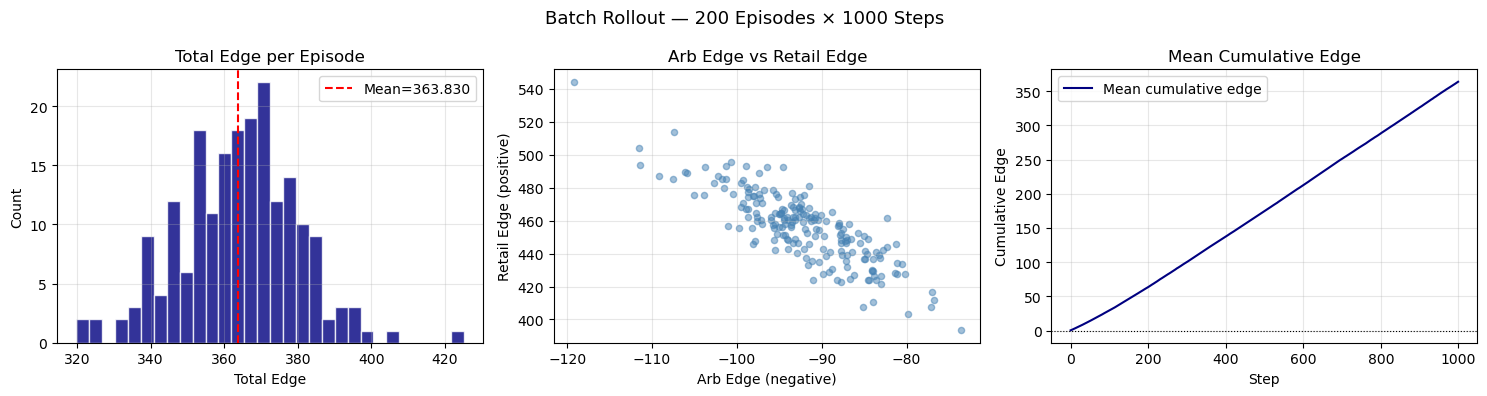

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Batch Rollout — {N_EPISODES} Episodes × {sim_params.num_steps} Steps", fontsize=13)

axes[0].hist(ep_total, bins=30, color="navy", alpha=0.8, edgecolor="white")
axes[0].axvline(ep_total.mean(), color="red", lw=1.5, linestyle="--",
                label=f"Mean={ep_total.mean():.3f}")
axes[0].set_title("Total Edge per Episode")
axes[0].set_xlabel("Total Edge")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(ep_arb, ep_retail, alpha=0.5, color="steelblue", s=20)
axes[1].set_title("Arb Edge vs Retail Edge")
axes[1].set_xlabel("Arb Edge (negative)")
axes[1].set_ylabel("Retail Edge (positive)")
axes[1].grid(True, alpha=0.3)

mean_cum = batch_total.mean(axis=0).cumsum()
axes[2].plot(mean_cum, color="navy", lw=1.5, label="Mean cumulative edge")
axes[2].axhline(0, color="black", lw=0.8, linestyle=":")
axes[2].set_title("Mean Cumulative Edge")
axes[2].set_xlabel("Step")
axes[2].set_ylabel("Cumulative Edge")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()